In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn import linear_model
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.kernel_ridge import KernelRidge
import tensorflow as tf
'''from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense'''


''' 
pour chaque méthodes:
- présentation de la méthode 
- présentation des hyperparamètres
- Discussion sur les choix d'implémentation
- Discussion sur l'influence des paramètres sur les résultats
- Analyse critique des résultats
'''

" \npour chaque méthodes:\n- présentation de la méthode \n- présentation des hyperparamètres\n- Discussion sur les choix d'implémentation\n- Discussion sur l'influence des paramètres sur les résultats\n- Analyse critique des résultats\n"

In [36]:
Dataset = pd.read_csv("AirQualityUCI.csv", sep=';', decimal=',')
# Corriger le format de l'heure
Dataset['Time'] = Dataset['Time'].str.replace('.', ':', regex=False)

# Créer la variable datetime
Dataset['Datetime'] = pd.to_datetime(
    Dataset['Date'] + ' ' + Dataset['Time'],
    format='%d/%m/%Y %H:%M:%S',
    errors='coerce'
)

# Trier les données
Dataset = Dataset.sort_values('Datetime')

Dataset = Dataset.replace(-200, np.nan)
# Supprimer les colonnes vides
Dataset = Dataset.drop(columns=["Unnamed: 15", "Unnamed: 16","NMHC(GT)"]) #trop de valeur manquantes ou vide
print(Dataset.info())

Dataset = Dataset.dropna() #supression valeurs manquantes
print(Dataset.shape)

# Variables cibles
Y = Dataset[['CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']] #CO(GT) : Carbon Monoxide, C6H6(GT) : Benzene, NOx(GT) : Nitrogen Oxides, NO2(GT) : Nitrogen Dioxide

# Variables explicatives
X = Dataset.drop(columns=['CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)', 'Date', 'Time', 'Datetime']) #tous le reste

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           9357 non-null   object        
 1   Time           9357 non-null   object        
 2   CO(GT)         7674 non-null   float64       
 3   PT08.S1(CO)    8991 non-null   float64       
 4   C6H6(GT)       8991 non-null   float64       
 5   PT08.S2(NMHC)  8991 non-null   float64       
 6   NOx(GT)        7718 non-null   float64       
 7   PT08.S3(NOx)   8991 non-null   float64       
 8   NO2(GT)        7715 non-null   float64       
 9   PT08.S4(NO2)   8991 non-null   float64       
 10  PT08.S5(O3)    8991 non-null   float64       
 11  T              8991 non-null   float64       
 12  RH             8991 non-null   float64       
 13  AH             8991 non-null   float64       
 14  Datetime       9357 non-null   datetime64[ns]
dtypes: datetime64[ns](1),

In [21]:
Dataset.shape

(6941, 15)

In [37]:
#separation des donnees entrainement et test, onsuppose que X_test appartient au futur, le but du projet est donc de le prédire

train_size = int(len(Dataset) * 0.8)

dates_train = Dataset['Datetime'].iloc[:train_size]
dates_test = Dataset['Datetime'].iloc[train_size:]

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

Y_train = Y.iloc[:train_size]
Y_test = Y.iloc[train_size:]
print(X_train.shape, X_test.shape)
print(Y_train.shape, Y_test.shape)

(5552, 8) (1389, 8)
(5552, 4) (1389, 4)


In [38]:
#standardisation des donnees
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [39]:
targets = ['CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']

---

# 1. Regression linéaire sans pénalisation Rigde

- Présentation de la methode

On suppose que Y dépend linéairement de X:
$$
Y_i = \beta_0 + X_i^{(1)} \beta_1+...+X_i^{(8)} \beta_8 + \varepsilon_i
$$

Il s'agit donc de résoudre le problème suivant:

$$
\mathrm{argmin}_{\beta \in \mathbb{R}^d} ( \|Y - X\beta\|_2^2)
$$

Ce problème est directement résolus de manière algébrique

- Choix d'implémentation

`fit_interceptbool, default=True`, ce paramêtre permet d'ajouter une constante $\beta_0$ au modèle. Ce choix est justifié par le fait que la variable Y n'est pas forcémeent nul à l'origine.

`tolfloat, default=1e-6`, nous n'allons pas modifier la valeur par défaut du critère d'arret.

In [40]:
reg = linear_model.LinearRegression()

In [41]:
reg.fit(X_train, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### - performance et analyse critique des résultats

Commençons par calculer l'erreur d'estimation

In [42]:
Y_estimated_reg = reg.predict(X_train)

In [43]:
print(mean_squared_error(Y_train.values,Y_estimated_reg))

1896.5039733929596


A présent étudions les performances du modèle en prévison

In [44]:
Y_pred_reg = reg.predict(X_test)

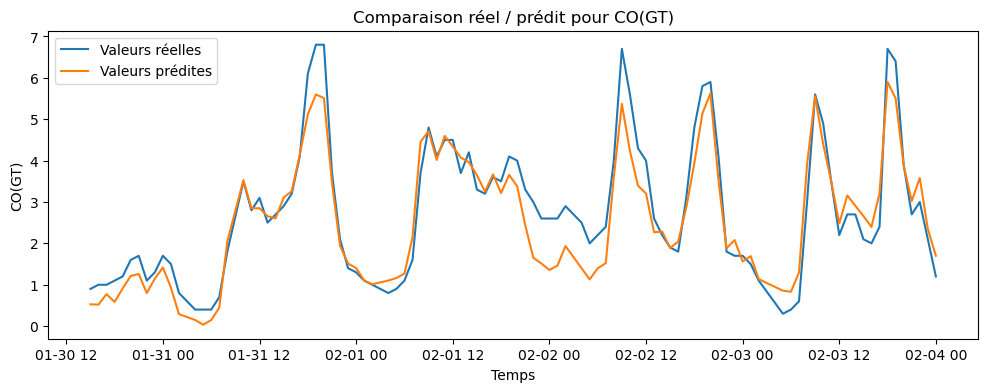

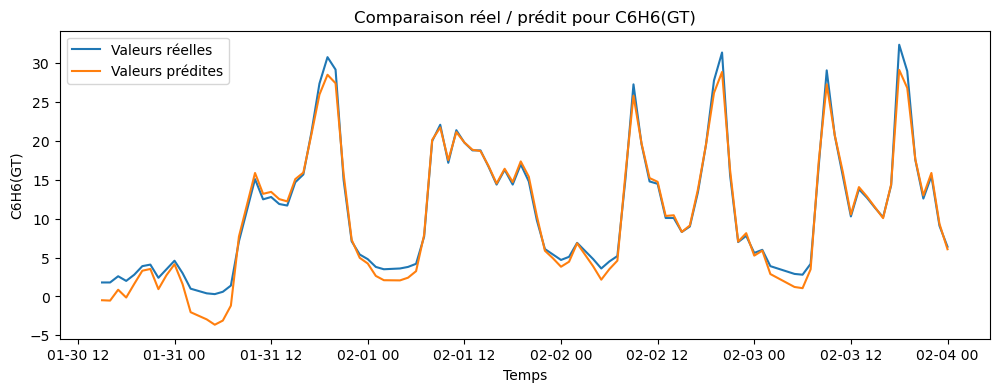

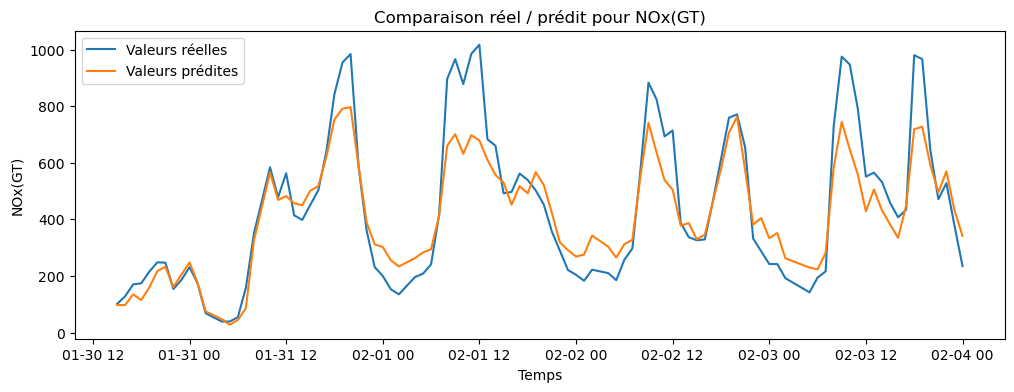

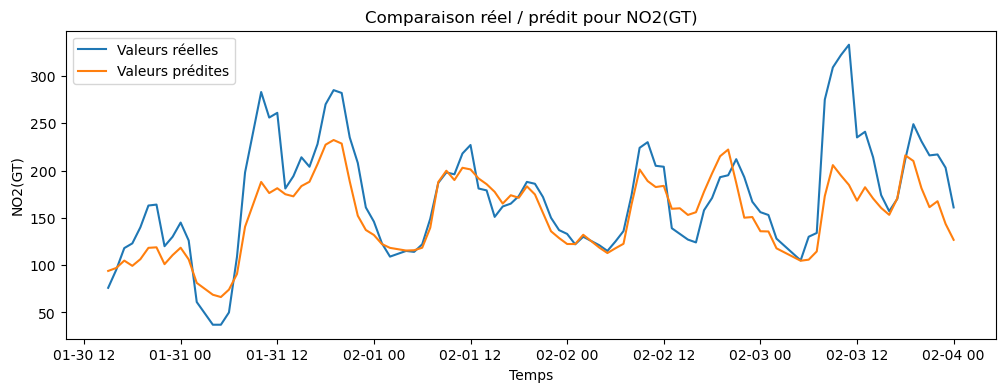

In [30]:
for i, target in enumerate(targets):
    plt.figure(figsize=(12, 4))
    
    plt.plot(dates_test[:100],Y_test[target].values[:100], label="Valeurs réelles")
    plt.plot(dates_test[:100],Y_pred_reg[:100, i], label="Valeurs prédites")
    
    plt.title(f"Comparaison réel / prédit pour {target}")
    plt.xlabel("Temps")
    plt.ylabel(target)
    plt.legend()
    
    plt.show()

In [45]:
mse_reg_test=mean_squared_error(Y_test.values,Y_pred_reg)
print("MSE global de la regression linéaire:",mse_reg_test)

rmse_par_variable = (mean_squared_error(Y_test.values,Y_pred_reg,multioutput='raw_values'))**0.5

print("RMSE par variable:", rmse_par_variable)

MSE global de la regression linéaire: 1840.362870886584
RMSE par variable: [ 0.48856098  1.50644567 77.67990917 36.39746042]


Le RMSE est à la même unité que les variables d'intérets, il est donc plus simple à interpréter que le MSE.

In [46]:
mean_y = Y_test[targets].mean().values
std_y = Y_test[targets].std().values

comparaison = pd.DataFrame({
    'Variable': targets,
    'mean': mean_y,
    'std': std_y,
    'RMSE': rmse_par_variable,
    'RMSE/mean': rmse_par_variable / mean_y,
    'RMSE/std': rmse_par_variable / std_y
})

print(comparaison)

   Variable        mean         std       RMSE  RMSE/mean  RMSE/std
0    CO(GT)    1.995392    1.308466   0.488561   0.244845  0.373385
1  C6H6(GT)    8.184521    6.305430   1.506446   0.184060  0.238912
2   NOx(GT)  304.459323  190.513777  77.679909   0.255141  0.407739
3   NO2(GT)  145.722102   51.585850  36.397460   0.249773  0.705571


L'erreur relative à la moyenne représente environs 20% de chaque variables, est l'erreur stantardisé est infèrieur à 1 pour chaque variable. On en conclu que la regression linéaire est un bon modèle.

On remarque que l'erreur du MSE est plus faible en prévision qu'en estimation, ce qui est innatendu. Nous allons vérifier si les données d'entrainement sont plus difficile à prédire que les données de test.

In [47]:

print("Écart-type sur Y_train \n", Y_train.std())
print("Écart-type sur Y_test \n",Y_test.std())

Écart-type sur Y_train 
 CO(GT)        1.468874
C6H6(GT)      7.614203
NOx(GT)     210.778646
NO2(GT)      42.838772
dtype: float64
Écart-type sur Y_test 
 CO(GT)        1.308466
C6H6(GT)      6.305430
NOx(GT)     190.513777
NO2(GT)      51.585850
dtype: float64


Il semble donc que l'estimation de `Y_train` a été perturbé par une plus grande variabilité des données d'entrainement pour `CO(GT)` , ` C6H6(GT)` et `NOx(GT)`.

Nous allons donc itérer le MSE pour differrents découpage du temps, nous utliserons `TimeSeriesSplit` au lieu de `train_test_split` pour respecter l'ordre chronologique.

In [49]:
tscv = TimeSeriesSplit(n_splits=20)

mse_test = []
mse_train = []

for train_index, test_index in tscv.split(X):
    X_tr, X_te = X.iloc[train_index], X.iloc[test_index]
    Y_tr, Y_te = Y.iloc[train_index], Y.iloc[test_index]

    sc = StandardScaler()
    X_tr = sc.fit_transform(X_tr)
    X_te = sc.transform(X_te)

    reg = linear_model.LinearRegression()
    reg.fit(X_tr, Y_tr)

    Y_pred = reg.predict(X_te)
    mse_test.append(mean_squared_error(Y_te, Y_pred))

    Y_estimated = reg.predict(X_tr)
    mse_train.append(mean_squared_error(Y_tr, Y_estimated))

print('mse train', np.sum(mse_train)/20)
print('mse test', np.sum(mse_test)/20)


mse train 937.950787220929
mse test 2377.381716899692


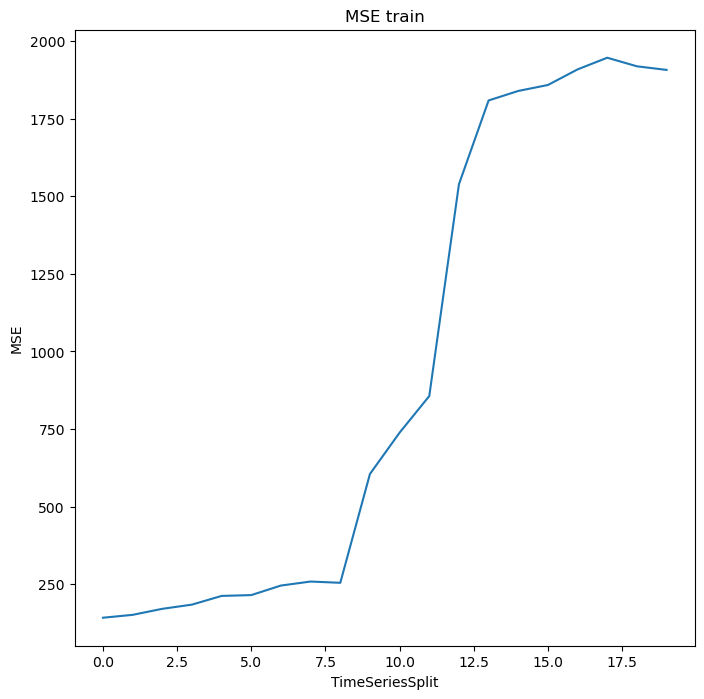

In [ ]:
plt.figure(1,figsize=(8,8))
plt.title("MSE train")
plt.xlabel("TimeSeriesSplit")
plt.ylabel('MSE')
plt.plot(mse_train)

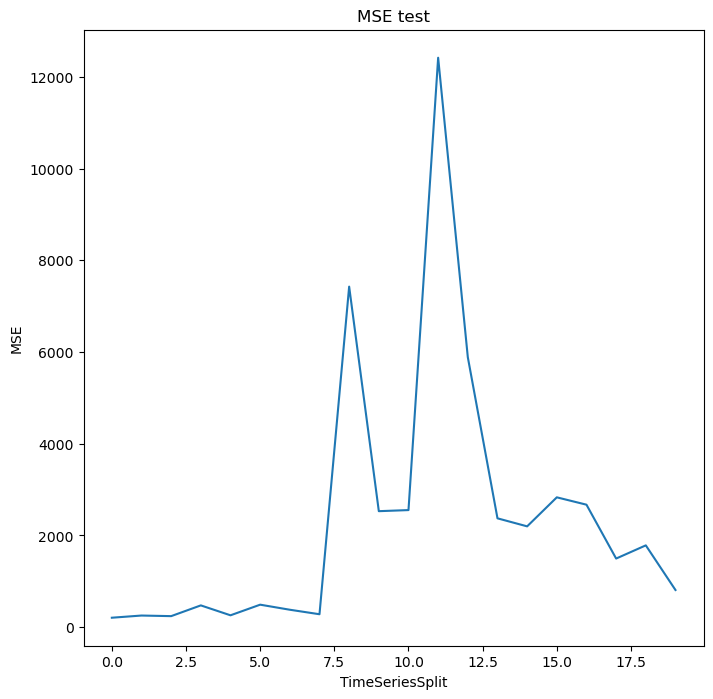

In [ ]:
plt.figure(1,figsize=(8,8))
plt.title("MSE test")
plt.xlabel("TimeSeriesSplit")
plt.ylabel('MSE')
plt.plot(mse_test)

Le `mse_train` augmente à chaque nouvelle itération, ce qui suggère que plus les données d'entrainement sont importantes plus les anomalies sont importantes et donc moins le modèle est performant pour les estimer.

On remarque une hausse rapide du `mse_train` entre la 7ème et 12ème itération, ce qui coincide aussi avec les pics du `mse_test`. Pourtant les données de test ont toujours la même taille, cette augmentation est donc liée à la période temporelle concernée.

---

## Régréssion avec pénalisation Ridge

- Présentation de la méthode

Cette méthode consiste à résoudre le problème suivant ou $\alpha$ est un coeeficient de régularisation :

$$
\mathrm{argmin}_{\beta \in \mathbb{R}^d} ( \|Y - X\beta\|_2^2 + \alpha \|\beta\|_2^2)
$$

- Présentation du coefficient de regression $\alpha$

(à compléter...)

- Discussion sur l'influence de $\alpha$ sur les résultats

Nous allons comparer différrente valeurs de $\alpha$ pour différrentes puissance de $10$, en nous basant sur une moyenne du MSE de différent découpage temporel. En effet un coefficient meilleur pour un découpage en particulier ne l'est pas forcément pour un autre.

In [ ]:
alphas = [0, 0.01, 0.1, 1, 10, 100]
tscv = TimeSeriesSplit(n_splits=5)

results = {}

for alpha in alphas:
    mse_test = []

    for train_index, test_index in tscv.split(X):
        X_tr, X_te = X.iloc[train_index], X.iloc[test_index]
        Y_tr, Y_te = Y.iloc[train_index], Y.iloc[test_index]

        sc = StandardScaler()
        X_tr = sc.fit_transform(X_tr)
        X_te = sc.transform(X_te)

        model = linear_model.Ridge(alpha=alpha)
        model.fit(X_tr, Y_tr)

        Y_pred = model.predict(X_te)

        mse_test.append(mean_squared_error(Y_te, Y_pred))

    results[alpha] = np.mean(mse_test)

print(results)

{0: np.float64(3399.584362981854), 0.01: np.float64(3399.687558227227), 0.1: np.float64(3400.6163757387258), 1: np.float64(3409.9073579187802), 10: np.float64(3501.59468259768), 100: np.float64(4182.964582722722)}


Le MSE augmente en fonction de $\alpha$ et le meilleur coefficient est 0, ce qui correspond à une régression sans pénalisation Ridge.  Donc la régularisation Ridge pour $\alpha>0$ n'a pas d'intéret. 


- Discussion sur les choix d'implémentation

(à compléter...)

---

# Méthode noyau

In [57]:
alphas = [0.00001,0.0001,0.001,0.01,1]
gammas = [0.00001,0.0001,0.001,0.01]

tscv = TimeSeriesSplit(n_splits=5, max_train_size=2000)  
results_grid = {}

for alpha in alphas:
    for gamma in gammas:
        mse_folds = []
        for train_idx, test_idx in tscv.split(X):
            X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
            Y_tr, Y_te = Y.iloc[train_idx], Y.iloc[test_idx]

            sc= StandardScaler()
            X_tr = sc.fit_transform(X_tr)
            X_te = sc.transform(X_te)

            m = KernelRidge(kernel='rbf', alpha=alpha, gamma=gamma)
            m.fit(X_tr, Y_tr)
            mse_folds.append(mean_squared_error(Y_te, m.predict(X_te)))

        results_grid[(alpha, gamma)] = np.mean(mse_folds)

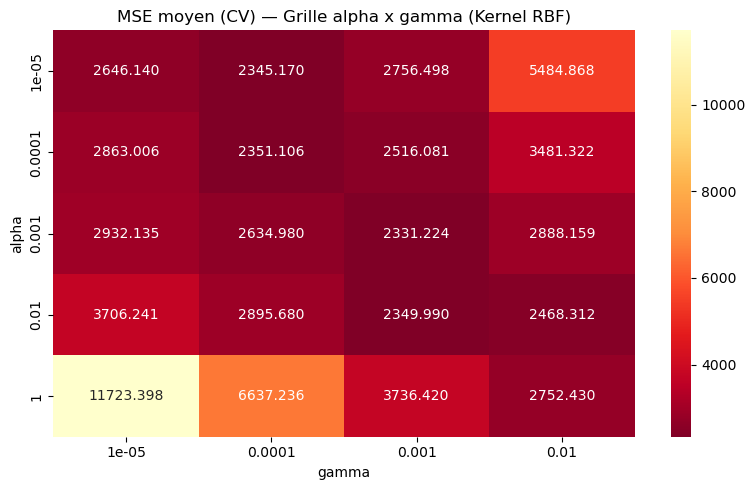

Meilleurs paramètres : alpha=0.001, gamma=0.001


In [59]:

# Affichage sous forme de heatmap
grid_matrix = np.array([[results_grid[(a, g)] for g in gammas] for a in alphas])

plt.figure(figsize=(8, 5))
sns.heatmap(
    grid_matrix,
    xticklabels=gammas,
    yticklabels=alphas,
    annot=True, fmt='.3f',
    cmap='YlOrRd_r'
)
plt.xlabel('gamma')
plt.ylabel('alpha')
plt.title('MSE moyen (CV) — Grille alpha x gamma (Kernel RBF)')
plt.tight_layout()
plt.show()

best_params = min(results_grid, key=results_grid.get)
best_alpha, best_gamma = best_params
print(f"Meilleurs paramètres : alpha={best_alpha}, gamma={best_gamma}")

In [60]:
mse_folds = []
for train_idx, test_idx in tscv.split(X):
    X_tr = X.iloc[train_idx]
    Y_tr = Y.iloc[train_idx]

    sc= StandardScaler()
    X_tr = sc.fit_transform(X_tr)

    m = KernelRidge(kernel='rbf', alpha=best_alpha, gamma=best_gamma)
    m.fit(X_tr, Y_tr)
    mse_folds.append(mean_squared_error(Y_tr, m.predict(X_tr)))

print("mse corrsepondant:")
print(f"mse train : {results_grid[best_params]:.4f}")
print ("mse test:",np.sum(mse_folds)/3)

mse corrsepondant:
mse train : 2331.2244
mse test: 1220.7085624239078


In [52]:
#performance en prévision
model_best = KernelRidge(kernel='rbf', alpha=best_alpha, gamma=best_gamma)

model_best.fit(X_train, Y_train)
Y_pred_best = model_best.predict(X_test)

mse_final  = mean_squared_error(Y_test, Y_pred_best)
rmse_final = mean_squared_error(Y_test, Y_pred_best, multioutput='raw_values') ** 0.5

print(f"MSE_test (alpha={best_alpha}, gamma={best_gamma}) : {mse_final:.4f}")
print(f"RMSE par variable : {rmse_final}")

MSE_test (alpha=0.01, gamma=0.001) : 1346.0352
RMSE par variable : [ 0.45886902  0.41288918 64.92567858 34.18209938]


In [ ]:

# Tableau final
comparaison_final = pd.DataFrame({
    'Variable':  targets,
    'mean':      Y_test[targets].mean().values,
    'std':       Y_test[targets].std().values,
    'RMSE':      rmse_final,
    'RMSE/mean': rmse_final / Y_test[targets].mean().values,
    'RMSE/std':  rmse_final / Y_test[targets].std().values
})
print(comparaison_final.to_string(index=False))

Variable       mean        std      RMSE  RMSE/mean  RMSE/std
  CO(GT)   1.887879   1.306741  0.425220   0.225237  0.325405
C6H6(GT)   8.174545   6.726192  0.365624   0.044727  0.054358
 NOx(GT) 261.760606 166.045038 43.610275   0.166604  0.262641
 NO2(GT) 118.266667  38.978154 18.921443   0.159990  0.485437


---

# Réseau de neurones

$\mathrm{argmin}_{\theta \in \mathbb{R}^d}{\ell_n(\theta) + \lambda \mathrm{pen}(\theta)}$

In [61]:
np.random.seed(42)
tf.random.set_seed(42)

In [91]:
def test_model(input_d,hidden_d, epochs=5, batch_size=7 ):
    '''
    Parameters
    ----------
    input_d : int
        Nombre de neurones dans la premiere couche.

    hidden_d : list[int]
        Liste contenant le nombre de neurones de chaque couche cachée

    n : int
        Nombre de couches cachee

    Returns
    -------
    None'''
    tscv = TimeSeriesSplit(n_splits=3, max_train_size=2000)  
    n=len(hidden_d)
    mse_test_nn = 0
    mse_train_nn = 0
    for train_index, test_index in tscv.split(X): #même tcv que methodes noyau: 3 folds, max train size: 2000
        #model desing
        model = tf.keras.models.Sequential()
        model.add(tf.keras.layers.Dense(input_d, input_shape=(8,), activation='relu'))
        for i in range(n):
            model.add(tf.keras.layers.Dense(hidden_d[i], activation='relu'))
        model.add(tf.keras.layers.Dense(4))

        model.compile(loss='mean_squared_error', optimizer='adam')

        X_tr, X_te = X.iloc[train_index], X.iloc[test_index]
        Y_tr, Y_te = Y.iloc[train_index], Y.iloc[test_index]

        sc = StandardScaler()
        X_tr = sc.fit_transform(X_tr)
        X_te = sc.transform(X_te)

        # Fit the model
        history = model.fit(X_tr, Y_tr, epochs=epochs, batch_size=batch_size, verbose=0, shuffle=False)

        #prediction
        Y_pred = model.predict(X_te)
        Y_estimated = model.predict(X_tr)

        #Mse
        mse_test_nn += mean_squared_error(Y_te, Y_pred)
        mse_train_nn += mean_squared_error(Y_tr,Y_estimated)

    print("MSE train :", mse_train_nn/3)
    print("MSE test :", mse_test_nn/3)
    
    return mse_train_nn/3, mse_test_nn/3

In [83]:
test_model(64,[32])

c:\Users\hp\miniconda3\envs\TPM1\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


c:\Users\hp\miniconda3\envs\TPM1\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


c:\Users\hp\miniconda3\envs\TPM1\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
MSE train : 1652.7230936686199
MSE test : 2820.5618489583335


(1652.7230936686199, 2820.5618489583335)

In [82]:
test_model(128,[64,32])

c:\Users\hp\miniconda3\envs\TPM1\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


c:\Users\hp\miniconda3\envs\TPM1\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


c:\Users\hp\miniconda3\envs\TPM1\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
MSE train : 1588.6736857096355
MSE test : 2801.6144205729165


(1588.6736857096355, 2801.6144205729165)

In [85]:
test_model(128,[128,64])

c:\Users\hp\miniconda3\envs\TPM1\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


c:\Users\hp\miniconda3\envs\TPM1\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


c:\Users\hp\miniconda3\envs\TPM1\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
MSE train : 1520.3758341471355
MSE test : 2685.95751953125


(1520.3758341471355, 2685.95751953125)

Ces tests montrent que le mse diminue lentement quand on augmente la taille du réseau, nous décidons de nous arréter à `test_model(128,[128,64])`. Car le modèle deviendrait trop complexe sans pour autant faire mieux que les methodes précédentes.

- Discussion sur `batch_size`

Testons un `batch_size` plus petit

In [92]:
test_model(128,[128,64], epochs=5, batch_size=5)

c:\Users\hp\miniconda3\envs\TPM1\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


c:\Users\hp\miniconda3\envs\TPM1\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


c:\Users\hp\miniconda3\envs\TPM1\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
MSE train : 1530.5416056315105
MSE test : 3515.614990234375


(1530.5416056315105, 3515.614990234375)

Avec une valeur plus petite, le MSE d’entraînement ne change pas vraiment mais le MSE de test augmente fortement, c'est un signe de surajustement. Le modèle généralise moins bien et fait en sorte que les données prédites soit trop similaires au données d'entrainement. 

In [93]:
test_model(128,[128,64], epochs=5, batch_size=10)

c:\Users\hp\miniconda3\envs\TPM1\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


c:\Users\hp\miniconda3\envs\TPM1\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


c:\Users\hp\miniconda3\envs\TPM1\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
MSE train : 1610.4393005371094
MSE test : 2852.46435546875


(1610.4393005371094, 2852.46435546875)

Avec une valeur plus grande, le MSE d’entraînement et le MSE de test augmentent. Le modèle apprend alors moins bien les données d’entraînement et donc sa capacité de prédiction est moins bonne. Cependant le temps d'execution et beaucoup plus court.

Nous retenons donc la valeur de 7

- Discussion de `epoch`

Nous allons réaliser une première étude avec un batch size plus grand pour réduire le coût de calcul, il faut prévoir un peu plus d'une minute.

In [102]:
epochs_list = [3,5, 10, 20]
mse=[]
for i in epochs_list:
    mse.append(test_model(128,[126,64],epochs=i, batch_size=30)[1])

c:\Users\hp\miniconda3\envs\TPM1\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


c:\Users\hp\miniconda3\envs\TPM1\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


c:\Users\hp\miniconda3\envs\TPM1\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MSE train : 2519.6806640625
MSE test : 4474.2333984375


c:\Users\hp\miniconda3\envs\TPM1\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


c:\Users\hp\miniconda3\envs\TPM1\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


c:\Users\hp\miniconda3\envs\TPM1\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MSE train : 1751.2891235351562
MSE test : 4092.7353515625


c:\Users\hp\miniconda3\envs\TPM1\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


c:\Users\hp\miniconda3\envs\TPM1\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


c:\Users\hp\miniconda3\envs\TPM1\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
MSE train : 1461.7432657877605
MSE test : 3747.7676595052085


c:\Users\hp\miniconda3\envs\TPM1\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


c:\Users\hp\miniconda3\envs\TPM1\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


c:\Users\hp\miniconda3\envs\TPM1\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MSE train : 1222.5824890136719
MSE test : 2870.175537109375


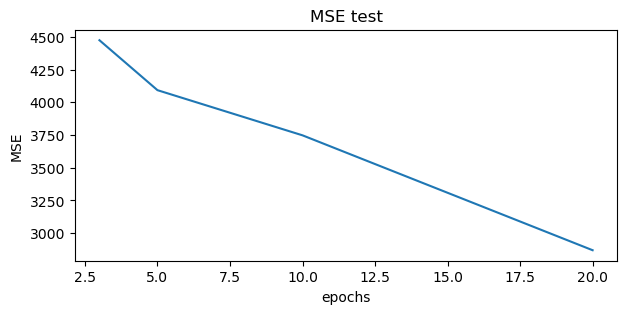

In [104]:
plt.figure(1,figsize=(7,3))
plt.title("MSE test")
plt.xlabel("epochs")
plt.ylabel('MSE')
plt.plot(epochs_list,mse)


Le mse test est décroissant en fonction de `epoch`. Nous allons donc essayer avec 20.

In [105]:
test_model(128,[126,64],epochs=20, batch_size=7)[1]

c:\Users\hp\miniconda3\envs\TPM1\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


c:\Users\hp\miniconda3\envs\TPM1\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


c:\Users\hp\miniconda3\envs\TPM1\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
MSE train : 1124.707270304362
MSE test : 2348.689697265625


2348.689697265625

Le temps de calcul est assez long, nous somme donc contraint de nous arréter là bien que nous n'avons pas atteint un minimum en `epoch`. Les résultats sont à présent meilleurs que les méthodes précédentes mais restent très proches de la regression linéaire.